Con 1 componente(s) se explica el 26.30% de la varianza.
Con 2 componente(s) se explica el 42.34% de la varianza.
Con 3 componente(s) se explica el 57.98% de la varianza.
Con 4 componente(s) se explica el 71.28% de la varianza.
Con 5 componente(s) se explica el 83.50% de la varianza.
Con 6 componente(s) se explica el 92.66% de la varianza.
Con 7 componente(s) se explica el 100.00% de la varianza.


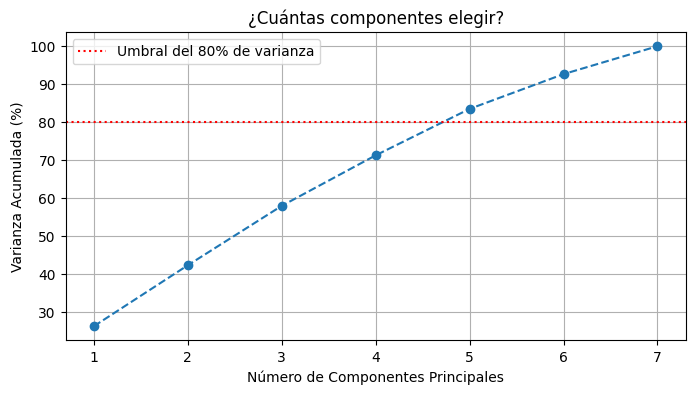


--- TABLA DE PESOS (LOADINGS) PARA LAS COMPONENTES ÓPTIMAS ---
                  PC1       PC2       PC3       PC4       PC5
Matematicas -0.332397 -0.042728  0.753899 -0.026174 -0.022833
Fisica      -0.090956  0.709108  0.104243  0.370957  0.551278
Quimica      0.277952 -0.513226 -0.037119  0.671434  0.196152
Literatura  -0.456174  0.147390 -0.422949 -0.075635 -0.273697
Historia    -0.440834 -0.214378 -0.433331  0.002631  0.484335
Arte         0.388031 -0.084730  0.003746 -0.628923  0.530299
Biologia     0.500984  0.396331 -0.229601  0.098033 -0.257658


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Creamos datos de ejemplo (50 alumnos, 7 materias)
np.random.seed(42)
datos = {
    "Matematicas": np.random.rand(50) * 10,
    "Fisica": np.random.rand(50) * 10,
    "Quimica": np.random.rand(50) * 10,
    "Literatura": np.random.rand(50) * 10,
    "Historia": np.random.rand(50) * 10,
    "Arte": np.random.rand(50) * 10,
    "Biologia": np.random.rand(50) * 10,
}
X = pd.DataFrame(datos)

# 2. Estandarizamos los datos
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

# 3. PASO CLAVE: Ejecutamos el PCA con TODAS las componentes (las 7) para evaluar cuáles sirven
pca_completo = PCA()
pca_completo.fit(X_escalado)

# 4. Calculamos cuánta varianza explica cada componente (en porcentaje)
varianza_explicada = pca_completo.explained_variance_ratio_ * 100
varianza_acumulada = np.cumsum(varianza_explicada)

# Mostramos la varianza acumulada para decidir (ej. buscar superar el 80%)
for i, var in enumerate(varianza_acumulada):
  print(f"Con {i+1} componente(s) se explica el {var:.2f}% de la varianza.")

# 5. (Opcional) Graficamos el Scree Plot para verlo visualmente
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, len(varianza_explicada) + 1),
    varianza_acumulada,
    marker="o",
    linestyle="--",
)
plt.axhline(
    y=80, color="r", linestyle=":", label="Umbral del 80% de varianza"
)
plt.xlabel("Número de Componentes Principales")
plt.ylabel("Varianza Acumulada (%)")
plt.title("¿Cuántas componentes elegir?")
plt.legend()
plt.grid()
plt.show()

# --- AQUÍ DECIDES EL NÚMERO ÓPTIMO (Supongamos que elegiste 3 tras ver el gráfico) ---
n_optimo = 5

# 6. Ejecutamos el PCA definitivo con el número óptimo y sacamos los pesos
pca_definitivo = PCA(n_components=n_optimo)
pca_definitivo.fit(X_escalado)

tabla_pesos = pd.DataFrame(
    pca_definitivo.components_.T,
    columns=[f"PC{i+1}" for i in range(n_optimo)],
    index=X.columns,
)

print("\n--- TABLA DE PESOS (LOADINGS) PARA LAS COMPONENTES ÓPTIMAS ---")
print(tabla_pesos)